In [1]:
%matplotlib inline
import numpy as np
import time
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.spatial import distance
from scipy import stats
from warnings import simplefilter
simplefilter(action="ignore", category=pd.errors.PerformanceWarning)

In [2]:
"""
You can start the code from here
"""

df_biofilm_filtered = pd.read_csv('Figurewise raw data/Biofilm_filtered.csv', index_col = 0)
df_biofilm_filtered

,3,8,28,32,42,64,70,78,100,108,...,t_27_enrichment,t_39_enrichment,t_45_enrichment,t_63_enrichment,t_73_enrichment,t_81_enrichment,t_99_enrichment,t_107_enrichment,t_115_enrichment,t_137_enrichment
barcode,,,,,,,,,,,,,,,,,,,,,
GCGTATCGGAACTAGAAGGG,0,1,7,3,1,0,3,1,3,3,...,0.301030,0.602060,0.301030,0.602060,1.255273,1.146128,0.903090,0.000000,0.000000,0.000000
ACTGGAGAGACGCTCCAAGT,0,5,1,0,2,0,1,2,0,0,...,0.301030,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.301030,0.000000
GTTTTTAAATGTGTGCCCGG,1,4,1,3,9,0,4,0,0,0,...,-0.301030,-0.301030,0.397940,0.301030,-0.301030,-0.301030,-0.301030,-0.301030,-0.301030,-0.301030
GTACTAAATTGATGCCCATT,10,0,0,0,0,0,0,2,3,0,...,-0.740363,-1.041393,-1.041393,-0.740363,-1.041393,-1.041393,-1.041393,-1.041393,-1.041393,-1.041393
GGCCAAAGTACCTGTTAAAT,7,4,4,4,6,10,5,9,3,4,...,-0.903090,-0.425969,0.096910,-0.903090,-0.903090,-0.425969,-0.903090,-0.903090,-0.425969,-0.903090
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
GGAGGTAATA-CTTTAGCCC,0,0,0,0,0,0,0,0,0,0,...,0.301030,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
CTTGACGGAGGGCTG-ATTC,0,0,0,0,0,0,0,0,0,0,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
CGCACAAGAGAACGCGAAAC,0,0,0,0,0,0,0,0,0,0,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.477121


In [3]:
"""
You can start the code from here
"""

df_biofilm_filtered = pd.read_csv('Figurewise raw data/Biofilm_filtered.csv', index_col = 0)

#Determination of number of unique barcodes at the initial time point detected in each sample.
sample_dict = {'Flask_A':['4'], 'Flask_B':['5'], 'Flask_C':['6'], 'Flask_D':['7'],\
               'Planktonic_A':['8'], 'Planktonic_B':['9'], 'Planktonic_C':['10'], 'Planktonic_D':['11'],\
               'Disc_A': ['12','13','14'],'Disc_B':['15','16','17'],'Disc_C':['18','19','20'],'Disc_D':['21','22','23']}

df_samples = pd.DataFrame(columns=['Sample','Source','Replicate','Nb'])

i = 0
for samples in sample_dict.keys():
    print(samples)
    for file in sample_dict[samples]:
        print(file)
        df_samples.loc[i, 'Sample'] = samples
        df_samples.loc[i, 'Source'] = samples.split('_')[0]
        df_samples.loc[i, 'Replicate'] = samples.split('_')[1]
        df_samples.loc[i, 'Nb'] = len(df_biofilm_filtered.loc[df_biofilm_filtered[file] > 0])
        print(len(df_biofilm_filtered.loc[df_biofilm_filtered[file] > 0]))
        i = i+1

df_samples.to_csv('Figurewise raw data/1C.Number_of_barcodes.csv')

Flask_A
4
81211
Flask_B
5
67836
Flask_C
6
79987
Flask_D
7
68040
Planktonic_A
8
86746
Planktonic_B
9
73092
Planktonic_C
10
80716
Planktonic_D
11
64981
Disc_A
12
21968
13
18835
14
16559
Disc_B
15
17797
16
18105
17
21953
Disc_C
18
27549
19
11582
20
13998
Disc_D
21
28942
22
18046
23
29329


In [4]:
print("Total number of barcodes: " + str(len(df_biofilm_filtered)))

Total number of barcodes: 169321


In [5]:
print("Total number of barcodes detected in inoculum: " + str(len(df_biofilm_filtered.loc[df_biofilm_filtered['3'] > 0])))

Total number of barcodes detected in inoculum: 88551


In [6]:
print("Total number of barcodes detected in initial binding experiment: " + str(len(df_biofilm_filtered[(df_biofilm_filtered[['4','5','6','7','8','9','10','11','12','13','14',\
                                          '15','16','17','18','19','20','21','22','23']] > 0).any(axis = 1)])))

Total number of barcodes detected in initial binding experiment: 131397


In [7]:
#Mean number of unique barcodes in the absence of a bottleneck
print(df_samples.loc[df_samples.Source != 'Disc'].Nb.mean())

#Standard deviation in the number of unique barcodes in the absence of a bottleneck
print(df_samples.loc[df_samples.Source != 'Disc'].Nb.std())


75326.125
7901.377121155165


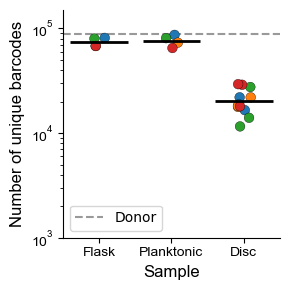

In [8]:
"""
Following plot is to compare number of unique barcodes detected in the initial time points
"""
plt.figure(figsize = [3,3])

#Construcy a strip plot to show each time point individually
sns.stripplot(data=df_samples, x="Source", y="Nb",  hue = 'Replicate', s=7, edgecolor='black', linewidth=0.25, legend = False)

#Construct a box plot to show median and variance in the population
sns.boxplot(data=df_samples, x="Source", y="Nb", showmeans = True, meanline = True,\
            medianprops = {'visible':False}, whiskerprops={'visible':False},zorder = 10, showfliers = False, showbox = False,\
           showcaps = False, meanprops = {'color': 'k', 'ls':'-','lw':2})


plt.axhline(y = len(df_biofilm_filtered.loc[df_biofilm_filtered['3'] > 0]),\
            color = 'gray', linestyle = '--', label = 'Donor', alpha = 0.8)
plt.ylim([1000,1.5*100000])
plt.yscale('log')
plt.legend()

plt.ylabel('Number of unique barcodes', fontname = 'arial', fontsize = 12)
plt.xlabel('Sample', fontname = 'arial', fontsize = 12)
plt.xticks(fontname = 'arial', fontsize = 10)
plt.yticks(fontname = 'arial', fontsize = 10)

# Remove top and right spines
sns.despine(top=True, right=True)

plt.tight_layout()
plt.savefig('Figures paper/Number_unique_barcodes.svg', format = 'svg', dpi = 300)

In [9]:
#Mean number of unique barcodes in the absence of a bottleneck
print("Mean number of unique barcodes in the absence of a bottleneck: ")
print(df_samples.loc[df_samples.Sample.str.find('Disc') < 0].Nb.mean())

#Standard deviation in the number of unique barcodes in the absence of a bottleneck
print("Standard deviation of the number of unique barcodes in the absence of a bottleneck: ")
print(df_samples.loc[df_samples.Sample.str.find('Disc') < 0].Nb.std())

Mean number of unique barcodes in the absence of a bottleneck: 
75326.125
Standard deviation of the number of unique barcodes in the absence of a bottleneck: 
7901.377121155165


In [10]:
#Do the statistics to compare the samples
import scipy.stats as stats

df_samples['Nb'] = pd.to_numeric(df_samples['Nb'], errors='coerce')

#Compare the planktonic and the Disc samples using Student's T-Test
print("Statistics upon comparing the biofilm planktonic data without bottleneck with that of the disc data for Number of unique barcodes")
print(stats.ttest_ind(df_samples.loc[df_samples.Source == 'Planktonic'].Nb, \
                      df_samples.loc[df_samples.Source == 'Disc'].Nb))

#Compare the planktonic and the flask samples using Student's T-Test
print("\nStatistics upon comparing the flask data without bottleneck with that of the biofilm planktonic data for Number of unique barcodes")
print(stats.ttest_ind(df_samples.loc[df_samples.Source == 'Planktonic'].Nb, \
                      df_samples.loc[df_samples.Source == 'Flask'].Nb))

Statistics upon comparing the biofilm planktonic data without bottleneck with that of the disc data for Number of unique barcodes
TtestResult(statistic=np.float64(14.467055239976265), pvalue=np.float64(8.20581663718791e-10), df=np.float64(14.0))

Statistics upon comparing the flask data without bottleneck with that of the biofilm planktonic data for Number of unique barcodes
TtestResult(statistic=np.float64(0.35415471183274855), pvalue=np.float64(0.7353366689598568), df=np.float64(6.0))


In [11]:
from scipy.stats import ks_2samp

#Compare the planktonic and the Disc samples using Kolmograv-Smirnoff test
print("Statistics upon comparing the biofilm planktonic data without bottleneck with that of the disc data for Number of unique barcodes")
print(stats.ks_2samp(df_samples.loc[df_samples.Source == 'Planktonic']['Nb'], \
                      df_samples.loc[df_samples.Source == 'Disc']['Nb']))

#Compare the planktonic and the flask samples using Kolmograv-Smirnoff test
print("\nStatistics upon comparing the flask data without bottleneck with that of the biofilm planktonic data for Number of unique barcodes")
print(stats.ks_2samp(df_samples.loc[df_samples.Source == 'Planktonic']['Nb'], \
                      df_samples.loc[df_samples.Source == 'Flask']['Nb']))

Statistics upon comparing the biofilm planktonic data without bottleneck with that of the disc data for Number of unique barcodes
KstestResult(statistic=np.float64(1.0), pvalue=np.float64(0.0010989010989010991), statistic_location=np.int64(29329), statistic_sign=np.int8(-1))

Statistics upon comparing the flask data without bottleneck with that of the biofilm planktonic data for Number of unique barcodes
KstestResult(statistic=np.float64(0.25), pvalue=np.float64(1.0), statistic_location=np.int64(64981), statistic_sign=np.int8(1))


In [12]:
print("Mean barcodes on disc: " + str(df_samples.loc[df_samples.Source == 'Disc'].Nb.mean()))

Mean barcodes on disc: 20388.583333333332


In [13]:
sample_dict = {'Flask_A':['4'], 'Flask_B':['5'], 'Flask_C':['6'], 'Flask_D':['7'],\
               'Planktonic_A':['8'], 'Planktonic_B':['9'], 'Planktonic_C':['10'], 'Planktonic_D':['11'],\
               'Disc_A': ['12','13','14'],'Disc_B':['15','16','17'],'Disc_C':['18','19','20'],'Disc_D':['21','22','23']}

df_samples = pd.DataFrame(columns=['Sample','Source','Replicate','Shannon Entropy','Distance'])

i = 0
for samples in sample_dict.keys():
    for file in sample_dict[samples]:
        df_samples.loc[i, 'Source'] = samples
        df_samples.loc[i, 'Sample'] = samples.split('_')[0]
        df_samples.loc[i, 'Replicate'] = samples.split('_')[1]
        df = df_biofilm_filtered.loc[df_biofilm_filtered['t_'+file+'_f'] > 0]
        df_samples.loc[i, 'Shannon Entropy'] = sum(-df['t_'+file+'_f']*df['t_'+file+'_f'].apply(np.log))
        df_samples.loc[i, 'Distance'] = distance.braycurtis(df_biofilm_filtered['t_3_f'].replace(np.nan,0),\
                                            df_biofilm_filtered['t_'+file+'_f'].replace(np.nan,0))
        i = i+1

df_samples.to_csv('Figurewise raw data/1D1E.Shannon-Bray Curtis from inoculum.csv')

KstestResult(statistic=np.float64(1.0), pvalue=np.float64(0.0010989010989010991), statistic_location=9.408926797487707, statistic_sign=np.int8(-1))
KstestResult(statistic=np.float64(0.25), pvalue=np.float64(1.0), statistic_location=10.622655684510105, statistic_sign=np.int8(1))


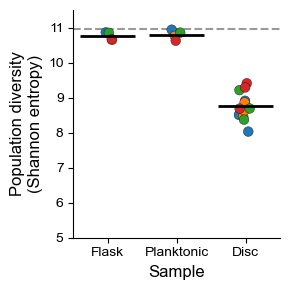

In [14]:
plt.figure(figsize = [3,3])
sns.stripplot(data=df_samples, x="Sample", y="Shannon Entropy",  hue = 'Replicate', s=7, edgecolor='black', linewidth=0.25, legend = False)
#sns.catplot(data=df_samples, x="Sample", y="Shannon Entropy", hue = 'Replicate', kind="swarm",height=3, aspect=1, legend = False)
sns.boxplot(data=df_samples, x="Sample", y="Shannon Entropy", showmeans = True, meanline = True,\
            medianprops = {'visible':False}, whiskerprops={'visible':False},zorder = 10, showfliers = False, showbox = False,\
           showcaps = False, meanprops = {'color': 'k', 'ls':'-','lw':2})
plt.axhline(y = 10.959197, color = 'gray', linestyle = '--', label = 'Donor', alpha = 0.8)
plt.ylim(5,11.5)

plt.ylabel('Population diversity\n(Shannon entropy)', fontname = 'arial', fontsize = 12)
plt.xlabel('Sample', fontname = 'arial', fontsize = 12)
plt.xticks(fontname = 'arial', fontsize = 10)
plt.yticks(fontname = 'arial', fontsize = 10)
# Remove top and right spines
sns.despine(top=True, right=True)
plt.tight_layout()


from scipy.stats import ks_2samp
print(stats.ks_2samp(df_samples.loc[df_samples.Sample == 'Planktonic']['Shannon Entropy'], \
                      df_samples.loc[df_samples.Sample == 'Disc']['Shannon Entropy']))

print(stats.ks_2samp(df_samples.loc[df_samples.Sample == 'Planktonic']['Shannon Entropy'], \
                      df_samples.loc[df_samples.Sample == 'Flask']['Shannon Entropy']))

plt.savefig('Figures paper/Initial shannon entropy - disc v plank.svg', format = 'svg', dpi = 300)

KstestResult(statistic=np.float64(1.0), pvalue=np.float64(0.0010989010989010991), statistic_location=np.float64(0.5158080000000002), statistic_sign=np.int8(1))
KstestResult(statistic=np.float64(0.5), pvalue=np.float64(0.7714285714285716), statistic_location=np.float64(0.4555960000000001), statistic_sign=np.int8(1))


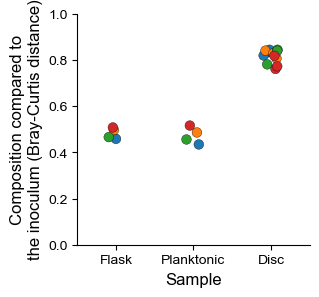

In [15]:
plt.figure(figsize = [3,3])
#df_plot = df_samples.loc[df_samples.Population_1 == 'Inoculum']
sns.stripplot(data=df_samples, x="Sample", y="Distance",  hue = 'Replicate', s=7, edgecolor='black', linewidth=0.25, legend = False)

plt.ylabel('Composition compared to\nthe inoculum (Bray-Curtis distance)', fontname = 'arial', fontsize = 12)
plt.xlabel('Sample', fontname = 'arial', fontsize = 12)
plt.xticks(fontname = 'arial', fontsize = 10)
plt.yticks(fontname = 'arial', fontsize = 10)
plt.ylim(0,1)

from scipy.stats import ks_2samp
print(stats.ks_2samp(df_samples.loc[df_samples.Sample == 'Planktonic']['Distance'], \
                      df_samples.loc[df_samples.Sample == 'Disc']['Distance']))

print(stats.ks_2samp(df_samples.loc[df_samples.Sample == 'Planktonic']['Distance'], \
                      df_samples.loc[df_samples.Sample == 'Flask']['Distance']))

# Remove top and right spines
sns.despine(top=True, right=True)

plt.savefig('Figures paper/Initial bray curtis inoculum.svg', format = 'svg', dpi = 300)

In [16]:
"""
The following code is to calculate the distance between disc and planktonic fraction,
other discs from same well and other discs from different wells
"""

sample_dict = {'Disc_A': ['8','12','13','14'],'Disc_B':['9','15','16','17'],\
               'Disc_C':['10','18','19','20'],'Disc_D':['11','21','22','23']}

df_samples = pd.DataFrame(columns=['Sample','Distance'])

i = 0
for samples in sample_dict.keys():

    #The following code is to calculate distance of each disc from planktonic
    df_samples.loc[i, 'Sample'] = 'Planktonic'
    df_samples.loc[i, 'Replicate'] = samples.split('_')[1]
    df_samples.loc[i, 'Distance'] = distance.braycurtis(df_biofilm_filtered[sample_dict[samples][0]].replace(np.nan,0),\
                                            df_biofilm_filtered[sample_dict[samples][1]].replace(np.nan,0))
    i = i + 1
    df_samples.loc[i, 'Sample'] = 'Planktonic'
    df_samples.loc[i, 'Replicate'] = samples.split('_')[1]
    df_samples.loc[i, 'Distance'] = distance.braycurtis(df_biofilm_filtered[sample_dict[samples][0]].replace(np.nan,0),\
                                            df_biofilm_filtered[sample_dict[samples][2]].replace(np.nan,0))
    i = i + 1
    df_samples.loc[i, 'Sample'] = 'Planktonic'
    df_samples.loc[i, 'Replicate'] = samples.split('_')[1]
    df_samples.loc[i, 'Distance'] = distance.braycurtis(df_biofilm_filtered[sample_dict[samples][0]].replace(np.nan,0),\
                                            df_biofilm_filtered[sample_dict[samples][2]].replace(np.nan,0))
    i = i + 1

    #The following code is to calculate distance of each disc from Disc from same well
    for sample_A in sample_dict[samples][1:4]:
        for sample_B in sample_dict[samples][1:4]:
            if sample_A != sample_B:
                df_samples.loc[i, 'Sample'] = 'Disc\n(Intra-well)'
                df_samples.loc[i, 'Replicate'] = samples.split('_')[1]
                df_samples.loc[i, 'Distance'] = distance.braycurtis(df_biofilm_filtered[sample_A].replace(np.nan,0),\
                                            df_biofilm_filtered[sample_B].replace(np.nan,0))
                i = i + 1

Well_A = ['12','13','14','18','19','20']
Well_B = ['15','16','17','21','22','23']

#The following code is to calculate distance of each disc from Disc from different well
for sample_A in Well_A:
    for sample_B in Well_B:
        df_samples.loc[i, 'Sample'] = 'Disc\n(Inter-well)'
        df_samples.loc[i, 'Replicate'] = 'E'
        df_samples.loc[i, 'Distance'] = distance.braycurtis(df_biofilm_filtered[sample_A].replace(np.nan,0),\
                                            df_biofilm_filtered[sample_B].replace(np.nan,0))
        i = i + 1
df_samples.to_csv('Figurewise raw data/1G.Bray Curtis between discs.csv')
df_samples.Replicate.value_counts()

Replicate
E    36
A     9
B     9
C     9
D     9
Name: count, dtype: int64

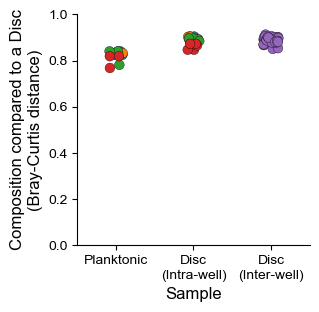

In [17]:

plt.figure(figsize = [3,3])

sns.stripplot(data=df_samples, x="Sample", y="Distance",  hue = 'Replicate', s=7, edgecolor='black', linewidth=0.25, legend = False)

plt.ylabel('Composition compared to a Disc\n(Bray-Curtis distance)', fontname = 'arial', fontsize = 12)
plt.xlabel('Sample', fontname = 'arial', fontsize = 12)
plt.xticks(rotation = 0, ha = 'center', fontname = 'arial', fontsize = 10)
plt.yticks(fontname = 'arial', fontsize = 10)
plt.ylim(0,1)


# Remove top and right spines
sns.despine(top=True, right=True)

plt.savefig('Figures paper/Initial bray curtis disc.svg', format = 'svg', dpi = 300)

12 2.5877109650189114
13 2.4471580313422194
14 2.250420002308894
15 2.436162647040756
16 2.574031267727719
17 2.3010299956639813
18 2.0827853703164503
19 2.292256071356476
20 2.513217600067939
21 2.0
22 2.4471580313422194
23 2.2833012287035497


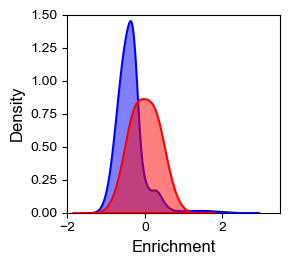

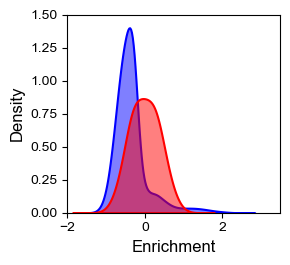

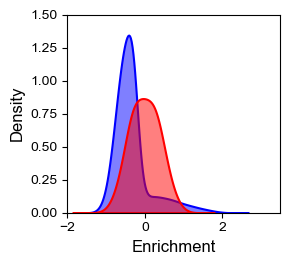

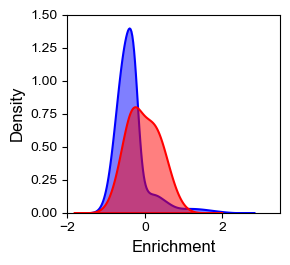

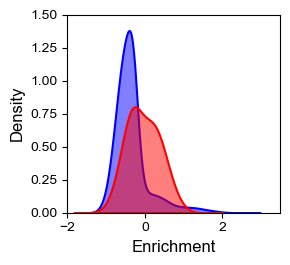

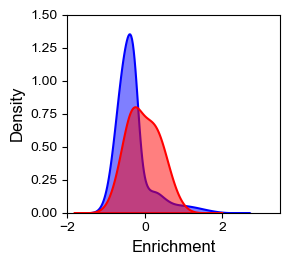

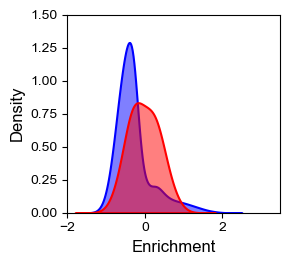

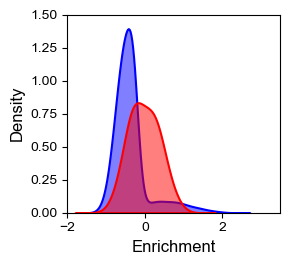

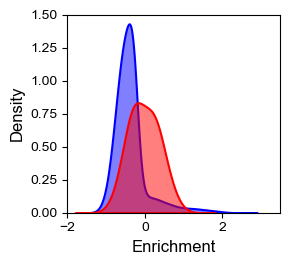

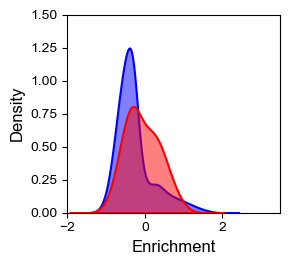

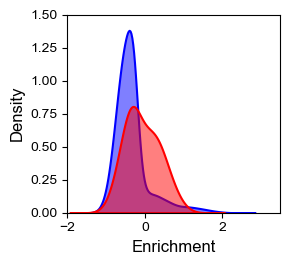

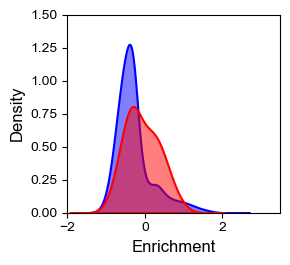

In [23]:
sample_dict = {'Disc_A': ['8','12','13','14'],'Disc_B':['9','15','16','17'],\
               'Disc_C':['10','18','19','20'],'Disc_D':['11','21','22','23']}

maximum_enrichment = []

for key in sample_dict.keys():
    for sample in sample_dict[key][1:4]:
        fig,ax = plt.subplots(figsize = [3,2.75])
        
        df_plot = df_biofilm_filtered.loc[(df_biofilm_filtered['3'] > 0) |\
                                              (df_biofilm_filtered[sample] > 0)]
        print(sample+' '+str(max(df_plot["t_"+sample+"_enrichment"])))
        maximum_enrichment.append(max(df_plot["t_"+sample+"_enrichment"]))
        sns.kdeplot(data=df_plot, x="t_"+sample+"_enrichment", linewidth=1.5,\
                    fill = True, color = 'blue', bw_adjust=3, ax =ax, alpha = 0.5, label = 'Disc')
    
        df_plot = df_biofilm_filtered.loc[(df_biofilm_filtered['3'] > 0) |\
                                              (df_biofilm_filtered[sample_dict[key][0]] > 0)]
        sns.kdeplot(data=df_plot, x="t_"+sample_dict[key][0]+"_enrichment", linewidth=1.5,\
                    fill = True, color = 'red', bw_adjust=5, ax =ax, alpha = 0.5, label = 'Planktonic')
        
        plt.xlabel('Enrichment', fontname='arial', fontsize = 12)
        plt.ylabel('Density', fontname='arial', fontsize = 12)
        plt.xlim([-2.0,3.5])
        plt.ylim([0,1.5])
        
        plt.xticks(fontname='arial',fontsize = 10);
        plt.yticks(fontname='arial',fontsize = 10);
        #plt.legend()
        plt.tight_layout()
        plt.savefig('Figures paper/Enrichment/Enrichment '+key+' '+sample+'.svg', format = 'svg', dpi = 300)


In [24]:
#Calculation of mean enrichment
np.mean(maximum_enrichment)

np.float64(2.351269267574093)

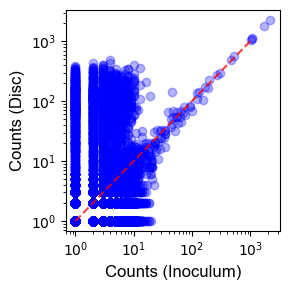

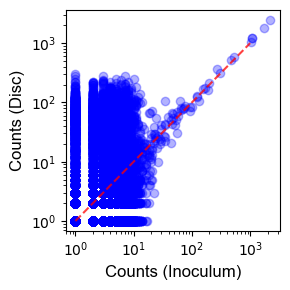

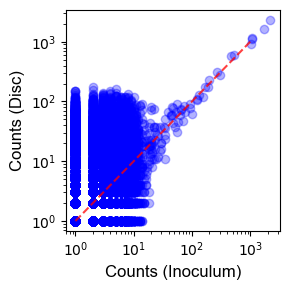

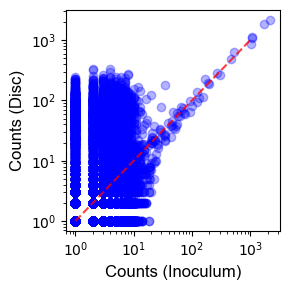

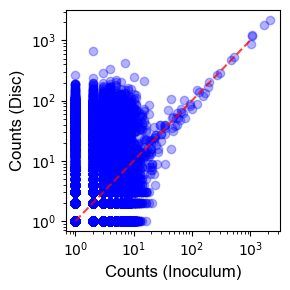

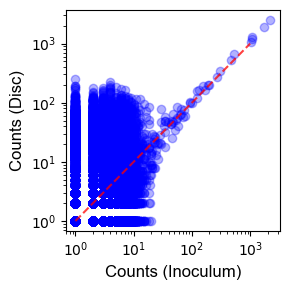

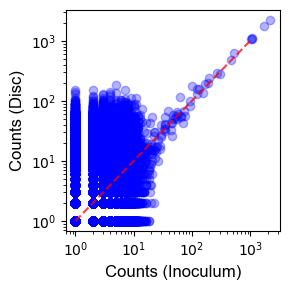

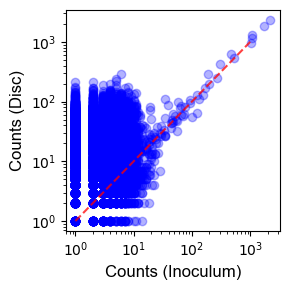

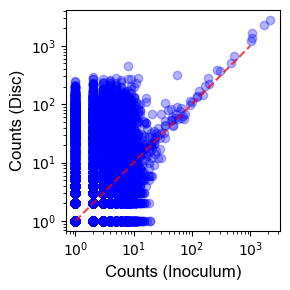

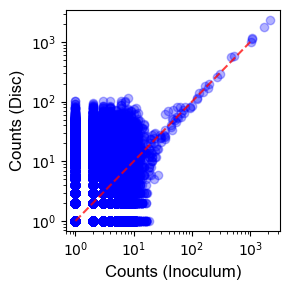

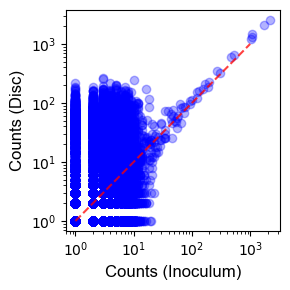

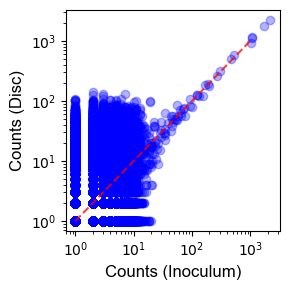

In [18]:
#Make the plots correlating each disc with the inoculum
list_files = ['12','13','14','15','16','17','18','19','20','21','22','23']

for i in list_files:
    plt.figure(figsize=[3,3])
    plt.plot([1,10,100,1000],[1,10,100,1000], '--', color = 'red', alpha = 0.75)
    
    plt.scatter(df_biofilm_filtered['3'], df_biofilm_filtered[str(i)], alpha = 0.3, color = 'blue', rasterized = True, label = 'Disc')
    #plt.scatter(df_biofilm_filtered.t_3_f, df_biofilm_filtered['t_8_f'], alpha = 0.1, color = 'red', rasterized = True, label = 'Planktonic')
    
    plt.xscale('log')
    plt.yscale('log')
    plt.xlabel('Counts (Inoculum)', fontname = 'Arial', fontsize = 12)
    plt.ylabel('Counts (Disc)', fontname = 'Arial', fontsize = 12)
    
    plt.tight_layout()
    plt.savefig('Figures paper/Correlation Donor Disc/Correlation Donor Disc '+ i +'.svg', format = 'svg', dpi = 300)

In [19]:
a = df_biofilm_filtered.t_8_enrichment.mean() + 1.96*df_biofilm_filtered.t_8_enrichment.std()
b = df_biofilm_filtered.t_9_enrichment.mean() + 1.96*df_biofilm_filtered.t_9_enrichment.std()
c = df_biofilm_filtered.t_10_enrichment.mean() + 1.96*df_biofilm_filtered.t_11_enrichment.std()
d = df_biofilm_filtered.t_11_enrichment.mean() + 1.96*df_biofilm_filtered.t_12_enrichment.std()
enrichment_values = [a,b,c,d]
enrichment_threshold = np.mean(enrichment_values)
enrichment_threshold

np.float64(0.622748887760707)

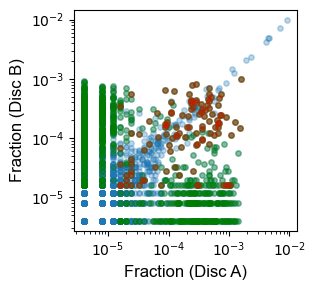

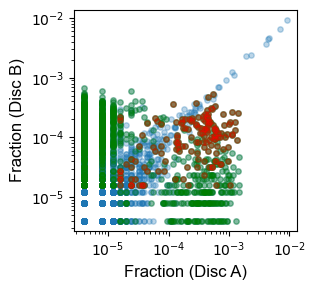

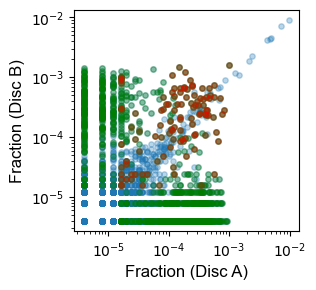

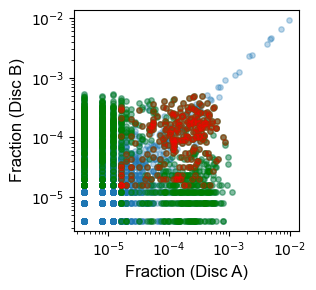

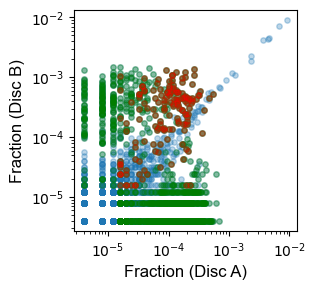

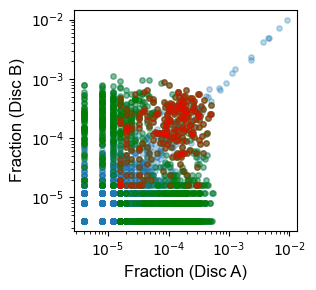

In [20]:
Disc_A = ['12','13','14']
Disc_B = ['12','13','14']

for i in range(0, len(Disc_A)):
    for j in range(0, len(Disc_A)):
        if Disc_A[i] != Disc_B[j]:
            df_plot = df_biofilm_filtered#.loc[(df_biofilm_filtered[Disc_A[i]] > 0) & (df_biofilm_filtered[Disc_B[j]] > 0)]
            
            #plot the correlation between the frequencies between the two discs
            plt.figure(figsize=[3.25,3])
            plt.scatter(df_plot['t_'+Disc_A[i]+'_f'],df_plot['t_'+Disc_B[j]+'_f'], s = 15, alpha = 0.3, rasterized = True)
        
            #plot the correlation between the frequencies for all barcodes enrihed in discA
            df1 = df_plot.loc[(df_plot['t_'+Disc_A[i]+'_enrichment'] >= enrichment_threshold)]
            plt.scatter(df1['t_'+Disc_A[i]+'_f'], df1['t_'+Disc_B[j]+'_f'], s = 15, alpha = 0.3, color = 'green', rasterized = True)
        
            #plot the correlation between the frequencies for all barcodes enrihed in discB
            df2 = df_plot.loc[(df_plot['t_'+Disc_B[j]+'_enrichment'] >= enrichment_threshold)]
            plt.scatter(df2['t_'+Disc_A[i]+'_f'], df2['t_'+Disc_B[j]+'_f'], s = 15, alpha = 0.3, color = 'green', rasterized = True)
        
            #plot the correlation between the frequencies for all barcodes enrihed in disc A amd disc B
            df3 = df_plot.loc[(df_plot['t_'+Disc_A[i]+'_enrichment'] >= enrichment_threshold) & (df_plot['t_'+Disc_B[j]+'_enrichment'] >= enrichment_threshold)]
            plt.scatter(df3['t_'+Disc_A[i]+'_f'], df3['t_'+Disc_B[j]+'_f'], s = 15, alpha = 0.3, color = 'red', rasterized = True)
            
            plt.xscale('log')
            plt.yscale('log')

            plt.xlabel('Fraction (Disc A)', fontname = 'Arial', fontsize = 12)
            plt.ylabel('Fraction (Disc B)', fontname = 'Arial', fontsize = 12)
            
            plt.tight_layout()
            
            plt.savefig('Figures paper/Correlation Disc Disc/Correlation Disc Disc '+ Disc_A[i] + Disc_B[j] +'.svg', format = 'svg', dpi = 300)
    

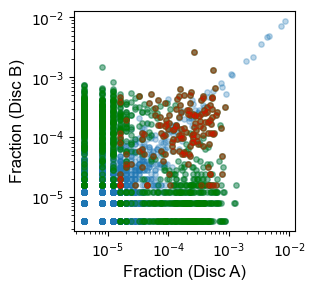

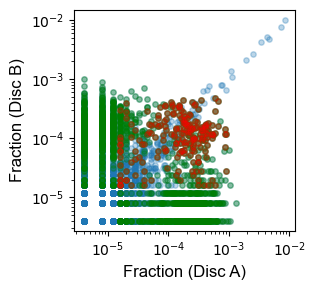

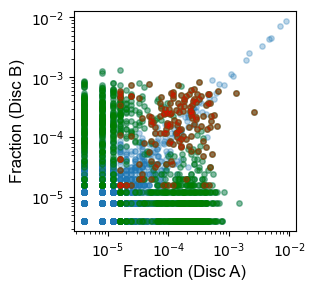

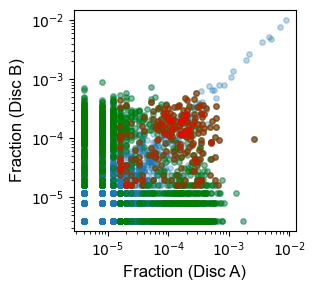

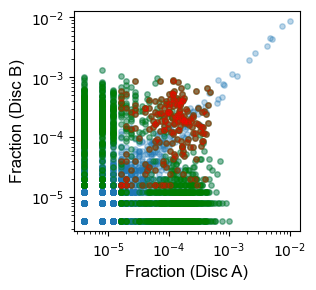

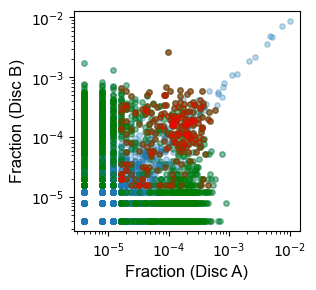

In [21]:
Disc_A = ['15','16','17']
Disc_B = ['15','16','17']

for i in range(0, len(Disc_A)):
    for j in range(0, len(Disc_A)):
        if Disc_A[i] != Disc_B[j]:
            df_plot = df_biofilm_filtered#.loc[(df_biofilm_filtered[Disc_A[i]] > 0) & (df_biofilm_filtered[Disc_B[j]] > 0)]
            
            #plot the correlation between the frequencies between the two discs
            plt.figure(figsize=[3.25,3])
            plt.scatter(df_plot['t_'+Disc_A[i]+'_f'],df_plot['t_'+Disc_B[j]+'_f'], s = 15, alpha = 0.3, rasterized = True)
        
            #plot the correlation between the frequencies for all barcodes enrihed in discA
            df1 = df_plot.loc[(df_plot['t_'+Disc_A[i]+'_enrichment'] >= enrichment_threshold)]
            plt.scatter(df1['t_'+Disc_A[i]+'_f'], df1['t_'+Disc_B[j]+'_f'], s = 15, alpha = 0.3, color = 'green', rasterized = True)
        
            #plot the correlation between the frequencies for all barcodes enrihed in discB
            df2 = df_plot.loc[(df_plot['t_'+Disc_B[j]+'_enrichment'] >= enrichment_threshold)]
            plt.scatter(df2['t_'+Disc_A[i]+'_f'], df2['t_'+Disc_B[j]+'_f'], s = 15, alpha = 0.3, color = 'green', rasterized = True)
        
            #plot the correlation between the frequencies for all barcodes enrihed in disc A amd disc B
            df3 = df_plot.loc[(df_plot['t_'+Disc_A[i]+'_enrichment'] >= enrichment_threshold) & (df_plot['t_'+Disc_B[j]+'_enrichment'] >= enrichment_threshold)]
            plt.scatter(df3['t_'+Disc_A[i]+'_f'], df3['t_'+Disc_B[j]+'_f'], s = 15, alpha = 0.3, color = 'red', rasterized = True)
            
            plt.xscale('log')
            plt.yscale('log')

            plt.xlabel('Fraction (Disc A)', fontname = 'Arial', fontsize = 12)
            plt.ylabel('Fraction (Disc B)', fontname = 'Arial', fontsize = 12)
            
            plt.tight_layout()
            
            plt.savefig('Figures paper/Correlation Disc Disc/Correlation Disc Disc '+ Disc_A[i] + Disc_B[j] +'.svg', format = 'svg', dpi = 300)

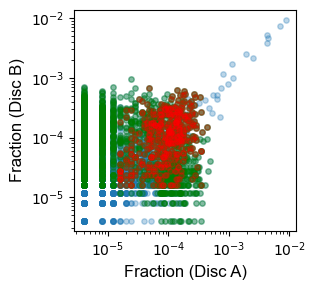

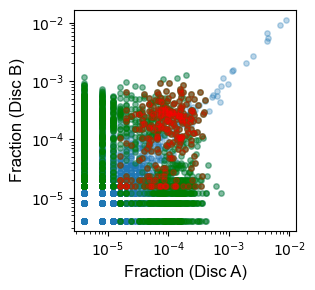

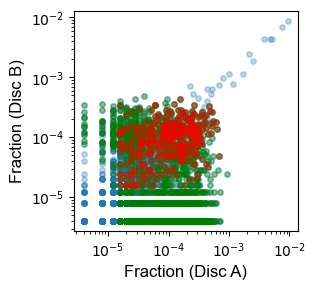

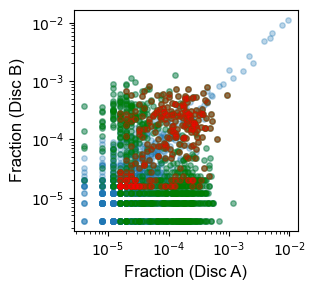

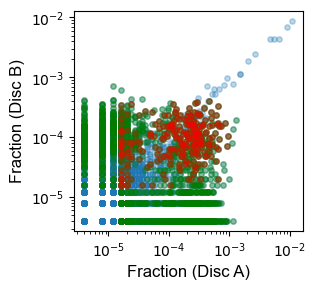

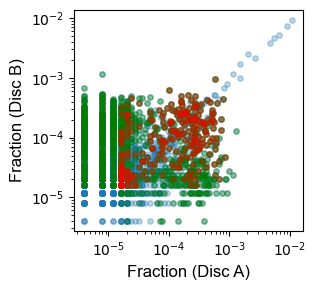

In [22]:
Disc_A = ['18','19','20']
Disc_B = ['18','19','20']

for i in range(0, len(Disc_A)):
    for j in range(0, len(Disc_A)):
        if Disc_A[i] != Disc_B[j]:
            df_plot = df_biofilm_filtered#.loc[(df_biofilm_filtered[Disc_A[i]] > 0) & (df_biofilm_filtered[Disc_B[j]] > 0)]
            
            #plot the correlation between the frequencies between the two discs
            plt.figure(figsize=[3.25,3])
            plt.scatter(df_plot['t_'+Disc_A[i]+'_f'],df_plot['t_'+Disc_B[j]+'_f'], s = 15, alpha = 0.3, rasterized = True)
        
            #plot the correlation between the frequencies for all barcodes enrihed in discA
            df1 = df_plot.loc[(df_plot['t_'+Disc_A[i]+'_enrichment'] >= enrichment_threshold)]
            plt.scatter(df1['t_'+Disc_A[i]+'_f'], df1['t_'+Disc_B[j]+'_f'], s = 15, alpha = 0.3, color = 'green', rasterized = True)
        
            #plot the correlation between the frequencies for all barcodes enrihed in discB
            df2 = df_plot.loc[(df_plot['t_'+Disc_B[j]+'_enrichment'] >= enrichment_threshold)]
            plt.scatter(df2['t_'+Disc_A[i]+'_f'], df2['t_'+Disc_B[j]+'_f'], s = 15, alpha = 0.3, color = 'green', rasterized = True)
        
            #plot the correlation between the frequencies for all barcodes enrihed in disc A amd disc B
            df3 = df_plot.loc[(df_plot['t_'+Disc_A[i]+'_enrichment'] >= enrichment_threshold) & (df_plot['t_'+Disc_B[j]+'_enrichment'] >= enrichment_threshold)]
            plt.scatter(df3['t_'+Disc_A[i]+'_f'], df3['t_'+Disc_B[j]+'_f'], s = 15, alpha = 0.3, color = 'red', rasterized = True)
            
            plt.xscale('log')
            plt.yscale('log')

            plt.xlabel('Fraction (Disc A)', fontname = 'Arial', fontsize = 12)
            plt.ylabel('Fraction (Disc B)', fontname = 'Arial', fontsize = 12)
            
            plt.tight_layout()
            
            plt.savefig('Figures paper/Correlation Disc Disc/Correlation Disc Disc '+ Disc_A[i] + Disc_B[j] +'.svg', format = 'svg', dpi = 300)

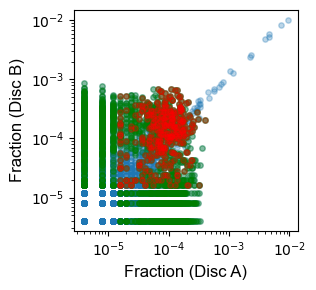

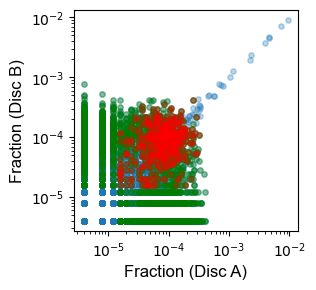

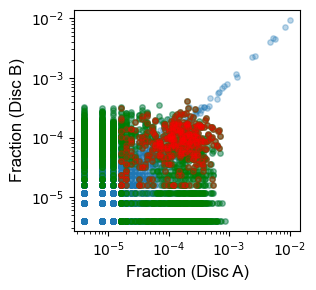

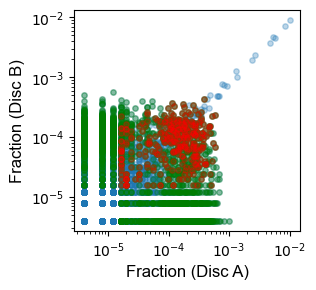

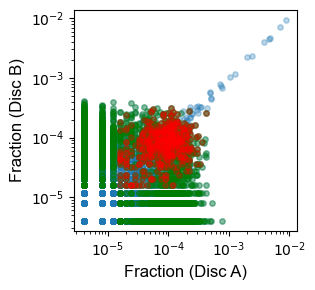

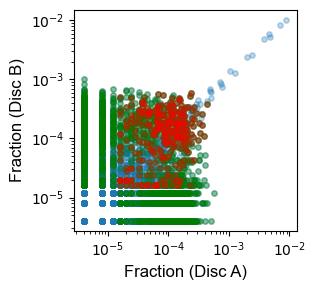

In [23]:
Disc_A = ['21','22','23']
Disc_B = ['21','22','23']

for i in range(0, len(Disc_A)):
    for j in range(0, len(Disc_A)):
        if Disc_A[i] != Disc_B[j]:
            df_plot = df_biofilm_filtered#.loc[(df_biofilm_filtered[Disc_A[i]] > 0) & (df_biofilm_filtered[Disc_B[j]] > 0)]
            
            #plot the correlation between the frequencies between the two discs
            plt.figure(figsize=[3.25,3])
            plt.scatter(df_plot['t_'+Disc_A[i]+'_f'],df_plot['t_'+Disc_B[j]+'_f'], s = 15, alpha = 0.3, rasterized = True)
        
            #plot the correlation between the frequencies for all barcodes enrihed in discA
            df1 = df_plot.loc[(df_plot['t_'+Disc_A[i]+'_enrichment'] >= enrichment_threshold)]
            plt.scatter(df1['t_'+Disc_A[i]+'_f'], df1['t_'+Disc_B[j]+'_f'], s = 15, alpha = 0.3, color = 'green', rasterized = True)
        
            #plot the correlation between the frequencies for all barcodes enrihed in discB
            df2 = df_plot.loc[(df_plot['t_'+Disc_B[j]+'_enrichment'] >= enrichment_threshold)]
            plt.scatter(df2['t_'+Disc_A[i]+'_f'], df2['t_'+Disc_B[j]+'_f'], s = 15, alpha = 0.3, color = 'green', rasterized = True)
        
            #plot the correlation between the frequencies for all barcodes enrihed in disc A amd disc B
            df3 = df_plot.loc[(df_plot['t_'+Disc_A[i]+'_enrichment'] >= enrichment_threshold) & (df_plot['t_'+Disc_B[j]+'_enrichment'] >= enrichment_threshold)]
            plt.scatter(df3['t_'+Disc_A[i]+'_f'], df3['t_'+Disc_B[j]+'_f'], s = 15, alpha = 0.3, color = 'red', rasterized = True)
            
            plt.xscale('log')
            plt.yscale('log')

            plt.xlabel('Fraction (Disc A)', fontname = 'Arial', fontsize = 12)
            plt.ylabel('Fraction (Disc B)', fontname = 'Arial', fontsize = 12)
            
            plt.tight_layout()
            
            plt.savefig('Figures paper/Correlation Disc Disc/Correlation Disc Disc '+ Disc_A[i] + Disc_B[j] +'.svg', format = 'svg', dpi = 300)
    

In [24]:
import numpy as np
import pandas as pd

# Compute enrichment threshold
cols = [f"t_{i}_enrichment" for i in range(8, 12)]
enrichment_values = [
    df_biofilm_filtered[col].mean() + 1.96 * df_biofilm_filtered[col].std()
    for col in cols
]
enrichment_threshold = np.mean(enrichment_values) + 1.96 * np.std(enrichment_values)

# Define disc groups
disc_groups = {
    'A': ['12', '13', '14'],
    'B': ['15', '16', '17'],
    'C': ['18', '19', '20'],
    'D': ['21', '22', '23']
}

# Build samples DataFrame
records = []
for replicate, discs in disc_groups.items():
    for disc in discs:
        mask = df_biofilm_filtered[f't_{disc}_enrichment'] >= enrichment_threshold
        fraction_sum = df_biofilm_filtered.loc[mask, f't_{disc}_f'].sum()
        records.append({
            'Sample': 'One disc',
            'Replicate': replicate,
            'Fraction': fraction_sum
        })

df_samples = pd.DataFrame(records)
df_samples

,Sample,Replicate,Fraction
0,One disc,A,0.820344
1,One disc,A,0.792944
2,One disc,A,0.753400
3,One disc,B,0.803632
4,One disc,B,0.782808
5,One disc,B,0.750036
6,One disc,C,0.696840
7,One disc,C,0.788996
8,One disc,C,0.794052
9,One disc,D,0.646792


In [25]:
import numpy as np
import pandas as pd
from itertools import combinations, product

# --- ENRICHMENT THRESHOLD ---
cols = [f"t_{i}_enrichment" for i in range(8, 12)]
enrichment_values = [
    df_biofilm_filtered[col].mean() + 1.96 * df_biofilm_filtered[col].std()
    for col in cols
]
enrichment_threshold = np.mean(enrichment_values) + 1.96 * np.std(enrichment_values)

# --- DISC GROUPS ---
disc_groups = {
    'A': ['12', '13', '14'],
    'B': ['15', '16', '17'],
    'C': ['18', '19', '20'],
    'D': ['21', '22', '23']
}

records = []

# --- ONE DISC ---
for replicate, discs in disc_groups.items():
    for disc in discs:
        mask = df_biofilm_filtered[f't_{disc}_enrichment'] >= enrichment_threshold
        fraction_sum = df_biofilm_filtered.loc[mask, f't_{disc}_f'].sum()
        records.append({
            'Sample': 'One disc',
            'Replicate': replicate,
            'Fraction': fraction_sum
        })

# --- TWO DISCS (SAME WELL) ---
for replicate, discs in disc_groups.items():
    for d1, d2 in combinations(discs, 2):
        mask = (
            (df_biofilm_filtered[f't_{d1}_enrichment'] >= enrichment_threshold) &
            (df_biofilm_filtered[f't_{d2}_enrichment'] >= enrichment_threshold)
        )
        df1 = df_biofilm_filtered.loc[mask]
        for disc in (d1, d2):
            records.append({
                'Sample': 'Two disc\nsame well',
                'Replicate': replicate,
                'Fraction': df1[f't_{disc}_f'].sum()
            })

# --- THREE DISCS (SAME WELL) ---
for replicate, discs in disc_groups.items():
    for d1, d2, d3 in combinations(discs, 3):
        mask = (
            (df_biofilm_filtered[f't_{d1}_enrichment'] >= enrichment_threshold) &
            (df_biofilm_filtered[f't_{d2}_enrichment'] >= enrichment_threshold) &
            (df_biofilm_filtered[f't_{d3}_enrichment'] >= enrichment_threshold)
        )
        df1 = df_biofilm_filtered.loc[mask]
        for disc in (d1, d2, d3):
            records.append({
                'Sample': 'Three disc\nsame wells',
                'Replicate': replicate,
                'Fraction': df1[f't_{disc}_f'].sum()
            })

# --- TWO DISCS (DIFFERENT WELLS) ---
group_keys = list(disc_groups.keys())
for g1, g2 in combinations(group_keys, 2):  # unique group pairs (A,B), (A,C), ...
    for d1 in disc_groups[g1]:
        for d2 in disc_groups[g2]:
            mask = (
                (df_biofilm_filtered[f't_{d1}_enrichment'] >= enrichment_threshold) &
                (df_biofilm_filtered[f't_{d2}_enrichment'] >= enrichment_threshold)
            )
            df1 = df_biofilm_filtered.loc[mask]
            for disc in (d1, d2):
                records.append({
                    'Sample': 'Two disc\ndifferent wells',
                    'Replicate': 'E',
                    'Fraction': df1[f't_{disc}_f'].sum()
                })

# --- FINAL DATAFRAME ---
df_samples = pd.DataFrame(records)
df_samples.to_excel('Figurewise raw data/1I. Disc_fraction_prbability.xlsx')

In [31]:
df_samples.loc[df_samples.Sample == 'Two disc\nsame well'].Fraction.mean()

np.float64(0.03864416666666667)

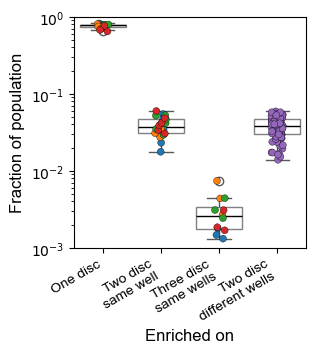

In [35]:
df_probability_enrichment = df_samples
plt.figure(figsize = [3,3])
sns.stripplot(data=df_probability_enrichment, x="Sample", y="Fraction", hue = 'Replicate', s=5, edgecolor='black', linewidth=0.25, legend = False)
sns.boxplot(x='Sample', y='Fraction', data=df_probability_enrichment,boxprops=dict(facecolor='white', edgecolor='gray'),
    medianprops=dict(color='black'))

plt.xticks(rotation = 30, ha = 'right', fontname = 'arial', fontsize = 10)
plt.xticks(fontname = 'arial', fontsize = 10)

plt.yscale('log')
plt.ylim([0.001,1])
plt.xlabel('Enriched on', fontname = 'Arial', fontsize = 12)
plt.ylabel('Fraction of population', fontname = 'Arial', fontsize = 12)
plt.savefig('Figures paper/Binding probability.svg', format = 'svg', dpi = 300)